# Volcanic Change Detection: Reykjanes Peninsula, Iceland
### SDS210 – Programming with Spatial Data

This notebook implements a change detection workflow to identify and 
quantify landscape changes caused by the 2023–2024 Sundhnúkur eruptions 
on the Reykjanes Peninsula, Iceland.

Three research questions are investigated:
- **RQ1:** Where did the most significant landscape changes occur between 2023 and 2024?
- **RQ2:** How does embedding-based change detection compare to a traditional spectral approach?
- **RQ3:** Which critical infrastructure sites fall within the areas of highest detected landscape change?

## 1. Setup & Parameters
### 1.1 Library Setup

In [1]:
# Standard library
from pathlib import Path

# Numerical and tabular
import numpy as np
import pandas as pd

# Vector data
import geopandas as gpd

# Raster data
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.windows import from_bounds
from rasterio.features import geometry_mask
import rasterio.windows


# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cmcrameri.cm as cmc

### 1.2 Helper functions
Functions used more than once are defined here so they can be called from any section below.

In [16]:
def get_mean_value_per_building(raster_path, buildings_gdf, column_name):
    """Extract mean raster value beneath each building footprint."""
    mean_values = []

    with rasterio.open(raster_path) as src:
        for idx, row in buildings_gdf.iterrows():
            try:
                out_image, _ = mask(src, [row.geometry], crop=True, nodata=np.nan)
                mean_val = float(np.nanmean(out_image))
            except Exception:
                # Building lies outside raster extent
                mean_val = np.nan
            mean_values.append(mean_val)

    result = buildings_gdf.copy()
    result[column_name] = mean_values
    return result

def build_ocean_mask(s2_path, ndwi_threshold=0.0, buffer_px=3):
    """Build a boolean ocean/water mask from a Sentinel-2 raster.

    Returns True for water pixels, False for land.
    A small buffer dilates the water area to suppress coastal noise.
    """
    with rasterio.open(s2_path) as src:
        band_names = list(src.descriptions)
        green = src.read(band_names.index("B3") + 1).astype(np.float32)
        nir   = src.read(band_names.index("B8") + 1).astype(np.float32)

    # NDWI: positive over water, negative over land
    with np.errstate(divide="ignore", invalid="ignore"):
        ndwi = (green - nir) / (green + nir)

    water = ndwi > ndwi_threshold

    # Dilate the water mask by a few pixels to suppress coastline noise
    for _ in range(buffer_px):
        water[1:, :]  |= water[:-1, :]
        water[:-1, :] |= water[1:, :]
        water[:, 1:]  |= water[:, :-1]
        water[:, :-1] |= water[:, 1:]

    return water

## 2. Data Loading


In [13]:
# Paths
DATA_RAW       = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
OUTPUT_DIR     = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Raster files exported from GEE
EMB_2023 = DATA_RAW / "AEF_embedding_2023.tif"
EMB_2024 = DATA_RAW / "AEF_embedding_2024.tif"
S2_2023  = DATA_RAW / "S2_composite_2023.tif"
S2_2024  = DATA_RAW / "S2_composite_2024.tif"

# Vector files
BUILDINGS_PRE      = DATA_RAW / "buildings_pre_eruption.geojson"
BUILDINGS_POST     = DATA_RAW / "buildings_post_eruption.geojson"
BUILDINGS_COMBINED = DATA_PROCESSED / "buildings_combined.geojson"

In [15]:
# Study parameters
AOI_NAME  = "Reykjanes Peninsula, Iceland"
YEAR_PRE  = 2023
YEAR_POST = 2024

# Change detection thresholds
CHANGE_THRESHOLD = 0.15    # embedding cosine change
DNBR_THRESHOLD   = 0.15    # spectral dNBR

# Ocean mask parameters
NDWI_THRESHOLD = 0.0       # > 0 = water
COAST_BUFFER_PX = 3        # widen water mask by 3 pixels (30 m)

print(f"Study area:   {AOI_NAME}")
print(f"Before/after: {YEAR_PRE}/{YEAR_POST}")

Study area:   Reykjanes Peninsula, Iceland
Before/after: 2023/2024


## 3. Inspection & Cleaning

### 3.1 Combine building footprints
Merging pre- and post-eruption OSM building datasets to get the most
complete picture of structures that existed before the eruptions. 


In [ ]:
# --- Inspect raster metadata ---
for filepath in [EMB_2023, EMB_2024, S2_2023, S2_2024]:
    with rasterio.open(filepath) as src:
        print(f"{filepath.name}")
        print(f"  CRS:   {src.crs}")
        print(f"  Bands: {src.count}")
        print(f"  Shape: {src.height} x {src.width}")

# --- Reproject buildings to raster CRS ---
with rasterio.open(EMB_2023) as src:
    raster_crs = src.crs

buildings_pre  = buildings_pre.to_crs(raster_crs)
buildings_post = buildings_post.to_crs(raster_crs)

AEF_embedding_2023.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
AEF_embedding_2024.tif
  CRS:   EPSG:32627
  Bands: 64
  Shape: 1723 x 2346
S2_composite_2023.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346
S2_composite_2024.tif
  CRS:   EPSG:32627
  Bands: 12
  Shape: 1723 x 2346


In [17]:
# --- Combine pre and post building datasets ---
buildings_combined = pd.concat([buildings_pre, buildings_post])
buildings_combined = buildings_combined.drop_duplicates(subset=["id"])
buildings_combined = gpd.GeoDataFrame(buildings_combined, crs=raster_crs)

# Filter buildings to those that lie within the raster extent
with rasterio.open(EMB_2023) as src:
    raster_bounds = src.bounds

within_extent = (
    (buildings_combined.geometry.centroid.x >= raster_bounds.left)  &
    (buildings_combined.geometry.centroid.x <= raster_bounds.right) &
    (buildings_combined.geometry.centroid.y >= raster_bounds.bottom) &
    (buildings_combined.geometry.centroid.y <= raster_bounds.top)
)
buildings_combined = buildings_combined[within_extent].copy()

buildings_combined.to_file(BUILDINGS_COMBINED, driver="GeoJSON")

# Destroyed candidates: in pre but not post
destroyed_candidates = buildings_pre[
    ~buildings_pre["id"].isin(buildings_post["id"])
]

print(f"Combined buildings (no doubles): {len(buildings_combined)}")
print(f"Buildings removed after eruption: {len(destroyed_candidates)}")

Combined buildings (no doubles): 1390
Buildings removed after eruption: 7


In [ ]:
# Ocean mask using 2023 Sentinel-2 (pre-eruption)
ocean_mask = build_ocean_mask(S2_2023, NDWI_THRESHOLD, COAST_BUFFER_PX)

print(f"Ocean/coastal pixels masked: {ocean_mask.sum():,}")
print(f"Total pixels:                {ocean_mask.size:,}")
print(f"Share masked:                {100 * ocean_mask.sum() / ocean_mask.size:.1f}%")

Ocean/coastal pixels masked: 914,902
Total pixels:                4,042,158
Share masked:                22.6%


## 4. RQ1 — Embedding-based change

In [19]:
# Load embedding rasters
with rasterio.open(EMB_2023) as src:
    emb_2023   = src.read(masked=True).astype(np.float32)
    emb_meta = src.profile

with rasterio.open(EMB_2024) as src:
    emb_2024 = src.read(masked=True).astype(np.float32)

# Normalize
norm_2023 = np.linalg.norm(emb_2023, axis=0, keepdims=True)
norm_2024 = np.linalg.norm(emb_2024, axis=0, keepdims=True)
emb_2023 = emb_2023 / np.where(norm_2023 == 0, 1, norm_2023)
emb_2024 = emb_2024 / np.where(norm_2024 == 0, 1, norm_2024)

# Cosine similarity = dot product & embeddings = unit vectors
similarity = np.sum(emb_2023 * emb_2024, axis=0)
change_map = 1 - similarity

# Build mask: any band nodata in either image
nodata_mask = emb_2023.mask.any(axis=0) | emb_2024.mask.any(axis=0)
change_map[nodata_mask] = np.nan

# Apply ocean/coastal mask
change_map[ocean_mask] = np.nan

print(f"Min change: {np.nanmin(change_map):.4f}")
print(f"Max change: {np.nanmax(change_map):.4f}")

Min change: 0.0043
Max change: 0.5354


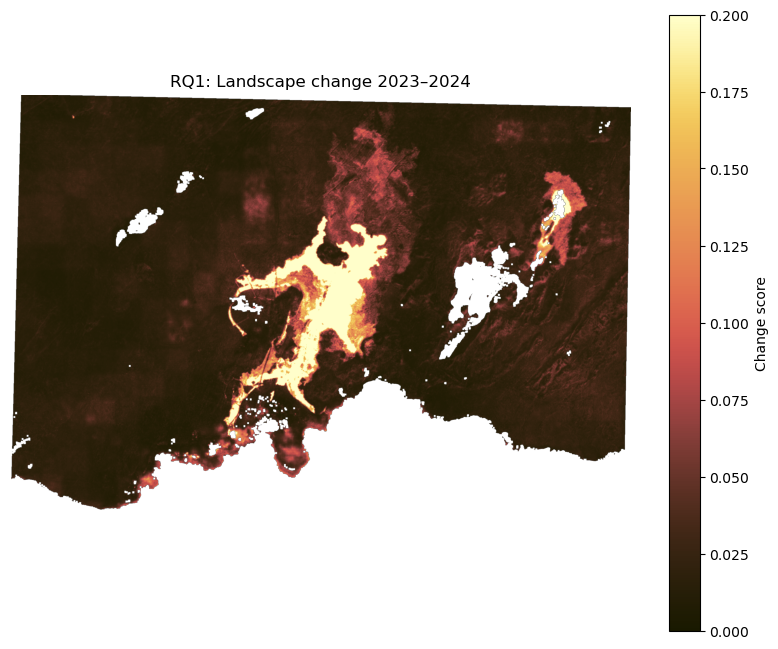

In [20]:
CHANGE_MAP_PATH = OUTPUT_DIR / "rq1_change_map.tif"
emb_meta.update(count=1, dtype="float32", nodata=np.nan)

with rasterio.open(CHANGE_MAP_PATH, "w", **emb_meta) as dst:
    dst.write(change_map.astype("float32"), 1)

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=0.2)
fig.colorbar(img, ax=ax, label="Change score")
ax.set_title(f"RQ1: Landscape change {YEAR_PRE}–{YEAR_POST}")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq1_change_map.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. RQ2 — Spectral dNBR comparison

In [21]:
# Find NIR and SWIR2 band indices from band names
with rasterio.open(S2_2023) as src:
    band_names = list(src.descriptions)
    dnbr_meta  = src.profile.copy()
    nir_2023   = src.read(band_names.index("B8")  + 1).astype(np.float32)
    swir_2023  = src.read(band_names.index("B12") + 1).astype(np.float32)

with rasterio.open(S2_2024) as src:
    nir_2024  = src.read(band_names.index("B8")  + 1).astype(np.float32)
    swir_2024 = src.read(band_names.index("B12") + 1).astype(np.float32)

with np.errstate(divide="ignore", invalid="ignore"):
    nbr_2023 = (nir_2023 - swir_2023) / (nir_2023 + swir_2023)
    nbr_2024 = (nir_2024 - swir_2024) / (nir_2024 + swir_2024)

dnbr = nbr_2023 - nbr_2024

# Apply ocean/coastal mask
dnbr[ocean_mask] = np.nan

print(f"dNBR min: {np.nanmin(dnbr):.4f}")
print(f"dNBR max: {np.nanmax(dnbr):.4f}")

# Save dNBR as GeoTIFF for use in RQ3
DNBR_MAP_PATH = OUTPUT_DIR / "rq2_dnbr_map.tif"

with rasterio.open(DNBR_MAP_PATH, "w", **dnbr_meta) as dst:
    dst.write(dnbr.astype("float32"), 1)

dNBR min: -0.6584
dNBR max: 0.8536


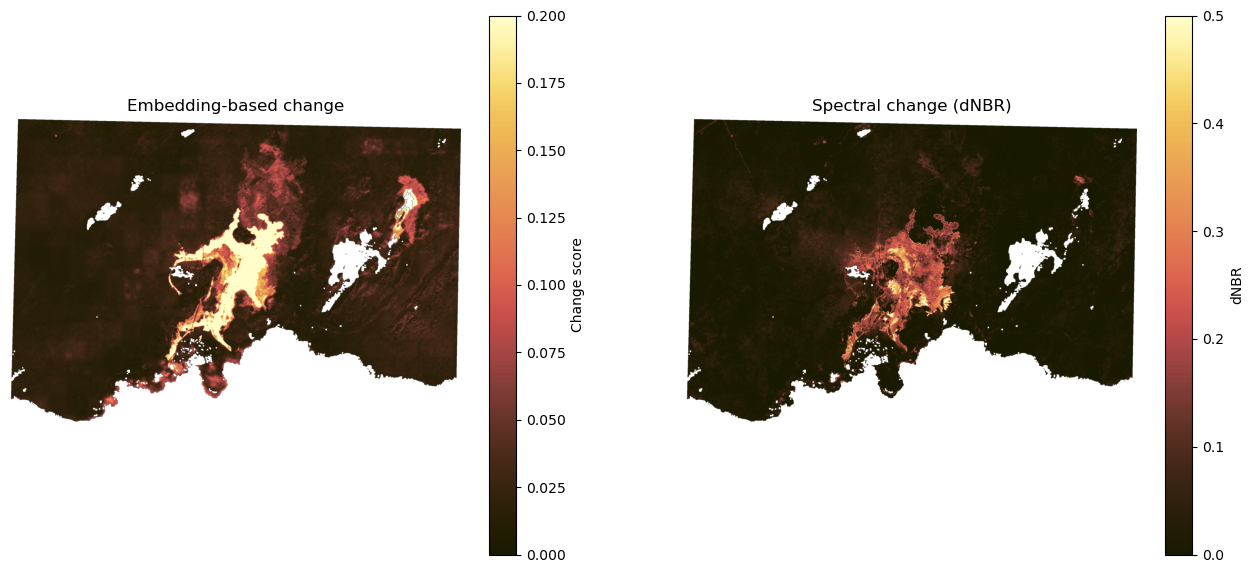

In [22]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

img1 = axs[0].imshow(change_map, cmap=cmc.lajolla, vmin=0, vmax=0.2)
fig.colorbar(img1, ax=axs[0], label="Change score")
axs[0].set_title("Embedding-based change")
axs[0].axis("off")

img2 = axs[1].imshow(dnbr, cmap=cmc.lajolla, vmin=0, vmax=0.5)
fig.colorbar(img2, ax=axs[1], label="dNBR")
axs[1].set_title("Spectral change (dNBR)")
axs[1].axis("off")

fig.savefig(OUTPUT_DIR / "rq2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Both methods agree (changed):    2.96%
Embedding only:                  1.07%
dNBR only:                       2.17%
Neither (no change):             93.80%


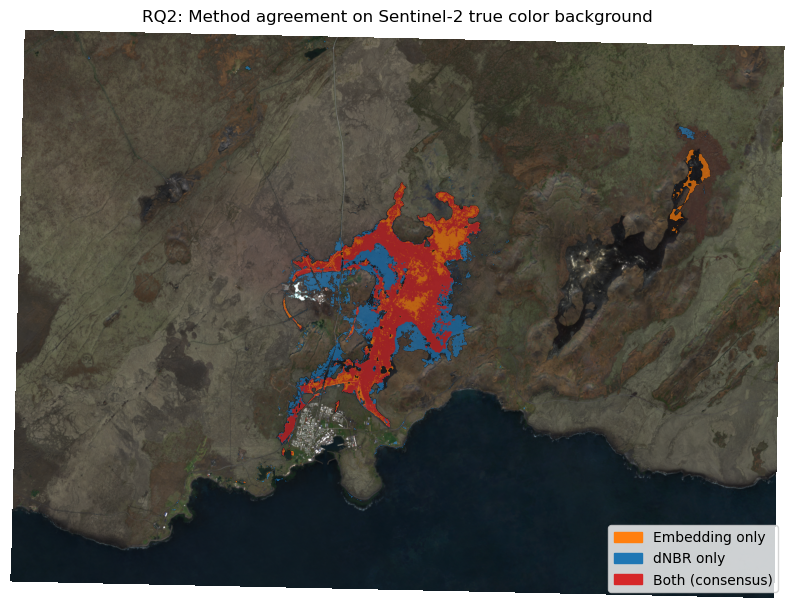

In [24]:
# Binary masks: True where each method detects significant change
emb_changed  = change_map >= CHANGE_THRESHOLD
dnbr_changed = dnbr       >= DNBR_THRESHOLD

# Build agreement map: 0=neither, 1=embedding only, 2=dNBR only, 3=both
agreement = np.zeros_like(change_map, dtype=int)
agreement[emb_changed  & ~dnbr_changed] = 1
agreement[~emb_changed &  dnbr_changed] = 2
agreement[emb_changed  &  dnbr_changed] = 3

# Mask nodata pixels
agreement = np.where(np.isnan(change_map), -1, agreement)

# Print share of each category
valid_pixels = ~np.isnan(change_map) & ~np.isnan(dnbr)
total = valid_pixels.sum()
both      = ((agreement == 3).sum() / total) * 100
emb_only  = ((agreement == 1).sum() / total) * 100
dnbr_only = ((agreement == 2).sum() / total) * 100
neither   = ((agreement == 0).sum() / total) * 100

print(f"Both methods agree (changed):    {both:.2f}%")
print(f"Embedding only:                  {emb_only:.2f}%")
print(f"dNBR only:                       {dnbr_only:.2f}%")
print(f"Neither (no change):             {neither:.2f}%")

# --- Visualization ---

# Load Sentinel-2 true color (Red, Green, Blue) as background
with rasterio.open(S2_2024) as src:
    band_names = list(src.descriptions)
    red   = src.read(band_names.index("B4") + 1).astype(float)
    green = src.read(band_names.index("B3") + 1).astype(float)
    blue  = src.read(band_names.index("B2") + 1).astype(float)

def normalize(array, vmax):
    """Clip and scale an array to 0-1 for display."""
    return np.clip(array, 0, vmax) / vmax

red_n   = normalize(red,   3000)
green_n = normalize(green, 3000)
blue_n  = normalize(blue,  3000)
true_color = np.dstack((red_n, green_n, blue_n))

# Hide "Neither" and nodata so background shows through
agreement_visible = np.where(agreement >= 1, agreement, np.nan)

# Plot: true color background, then agreement on top
cmap = ListedColormap(["tab:orange", "tab:blue", "tab:red"])

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(true_color)
ax.imshow(agreement_visible, cmap=cmap, vmin=1, vmax=3, alpha=0.7)

legend_handles = [
    mpatches.Patch(color="tab:orange", label="Embedding only"),
    mpatches.Patch(color="tab:blue",   label="dNBR only"),
    mpatches.Patch(color="tab:red",    label="Both (consensus)")
]
ax.legend(handles=legend_handles, loc="lower right")

ax.set_title("RQ2: Method agreement on Sentinel-2 true color background")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq2_agreement_map.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. RQ3 — Infrastructure impact


In [25]:
# Apply the helper function twice: once for embedding change, once for dNBR
buildings_with_change = get_mean_value_per_building(
    CHANGE_MAP_PATH, buildings_combined, "mean_change"
)
buildings_with_change = get_mean_value_per_building(
    DNBR_MAP_PATH, buildings_with_change, "mean_dnbr"
)

# Option B: a building is lava-affected only if BOTH methods agree
buildings_with_change["change_class"] = "low"
both_high = (
    (buildings_with_change["mean_change"] >= CHANGE_THRESHOLD) &
    (buildings_with_change["mean_dnbr"]   >= DNBR_THRESHOLD)
)
buildings_with_change.loc[both_high, "change_class"] = "high"

# Summary
n_high  = (buildings_with_change["change_class"] == "high").sum()
n_total = len(buildings_with_change)

print(f"Total buildings:                  {n_total}")
print(f"Affected by lava (both methods):  {n_high} ({100 * n_high / n_total:.1f}%)")
print()
print("Top 10 most affected buildings:")
print(
    buildings_with_change[["id", "mean_change", "mean_dnbr", "change_class"]]
    .sort_values("mean_change", ascending=False)
    .head(10)
)

# Save results
buildings_with_change.to_file(
    OUTPUT_DIR / "rq3_buildings_with_change.geojson",
    driver="GeoJSON"
)

/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_68246/4134952783.py:9: RuntimeWarning: Mean of empty slice
  mean_val = float(np.nanmean(out_image))
/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_68246/4134952783.py:9: RuntimeWarning: Mean of empty slice
  mean_val = float(np.nanmean(out_image))
/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_68246/4134952783.py:9: RuntimeWarning: Mean of empty slice
  mean_val = float(np.nanmean(out_image))
/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_68246/4134952783.py:9: RuntimeWarning: Mean of empty slice
  mean_val = float(np.nanmean(out_image))
/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_68246/4134952783.py:9: RuntimeWarning: Mean of empty slice
  mean_val = float(np.nanmean(out_image))
/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_68246/4134952783.py:9: RuntimeWarning: Mean of empty slice
  mean_val = float(np.nanmean(out_image))
/var/folders/md/94r6wf957t32536vlsm17t20

Total buildings:                  1390
Affected by lava (both methods):  0 (0.0%)

Top 10 most affected buildings:
                  id  mean_change  mean_dnbr change_class
1377  way/1241602606     0.160841   0.002318          low
1056   way/548381293     0.159562  -0.000556          low
1057   way/548381294     0.140010  -0.001567          low
1055   way/548381292     0.127957  -0.004909          low
743    way/493268673     0.124340   0.008290          low
745    way/493268675     0.122306  -0.000467          low
747    way/493268677     0.121523  -0.006563          low
744    way/493268674     0.119873  -0.001099          low
1299  way/1009856525     0.115946  -0.002231          low
1168   way/812387471     0.111313   0.002963          low


/var/folders/md/94r6wf957t32536vlsm17t200000gn/T/ipykernel_68246/675007998.py:11: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  high_change.plot(ax=ax, color="red",   alpha=0.8, linewidth=0.5)


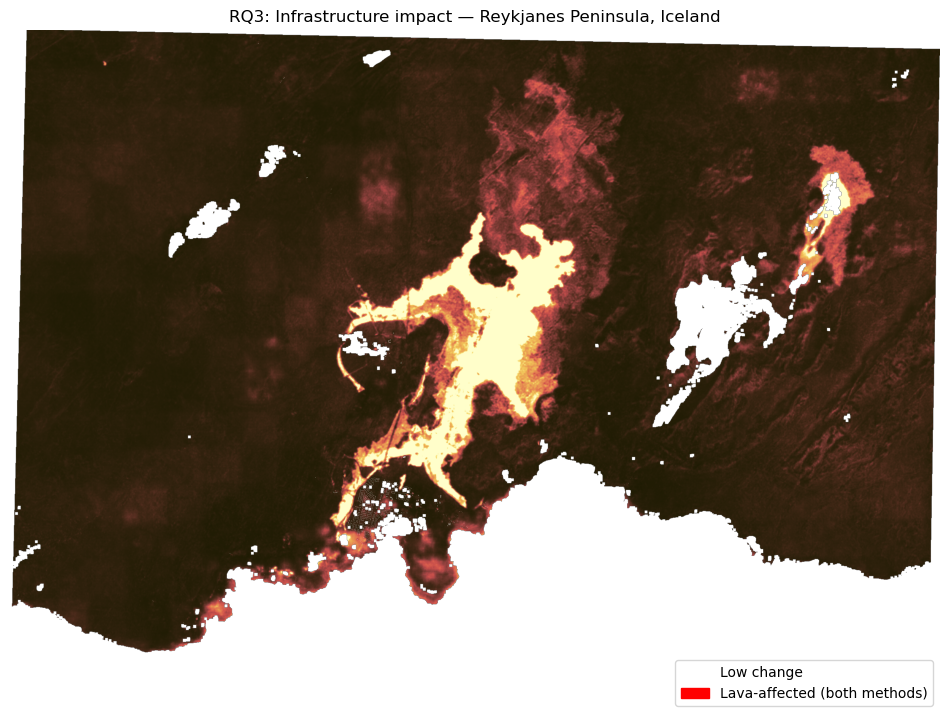

In [26]:
fig, ax = plt.subplots(figsize=(12, 9))

# Plot raster in geographic coordinates
show(change_map, transform=emb_meta["transform"],
     ax=ax, cmap=cmc.lajolla, vmin=0, vmax=0.2)

low_change  = buildings_with_change[buildings_with_change["change_class"] == "low"]
high_change = buildings_with_change[buildings_with_change["change_class"] == "high"]

low_change.plot(ax=ax,  color="white", alpha=0.4, linewidth=0.3)
high_change.plot(ax=ax, color="red",   alpha=0.8, linewidth=0.5)

legend_handles = [
    mpatches.Patch(color="white", label="Low change"),
    mpatches.Patch(color="red",   label=f"Lava-affected (both methods)")
]
ax.legend(handles=legend_handles, loc="lower right")
ax.set_title(f"RQ3: Infrastructure impact — {AOI_NAME}")
ax.axis("off")
fig.savefig(OUTPUT_DIR / "rq3_infrastructure.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Summary

### Interpretation

- The embedding-based change map and the dNBR map both highlight the
  Sundhnúkur fissure area and the lava flows toward Grindavík.
- The dNBR map is more focused on surface reflectance change, while the
  embedding map captures a broader notion of landscape change.


### Limitations

- The AlphaEarth embeddings are annual composites — we cannot
  distinguish between the individual eruption events of 2024.
- OSM building footprints depend on voluntary mapping and may
  miss small or recently destroyed structures.
- Cloud cover in Iceland is high; the May–September Sentinel-2
  composite mitigates but does not fully remove this.